In [10]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
dataset_filepath = "application_resource_average_usage_data.csv"

In [12]:
df = pd.read_csv(dataset_filepath)
df.head()

,CPU_Usage(%),Memory_Usage(MB),Disk_IO(MB/s),Network_Usage(Mbps),GPU_Utilization(%),Execution_Time(sec),Response_Time(ms),Requests_per_sec,Error_Rate(%),Crash_Frequency,Memory_Leak_Rate(MB/sec),User_Load,Peak_Idle_Ratio,Application_Category
0,22.845913,1436.729325,46.860716,114.619811,-4.189254,5.038115,68.183387,171.929397,1.045313,0,0.380991,766.736791,0.039245,Efficient
1,64.428575,2527.157227,138.503438,140.988676,37.109380,4.501069,759.244882,71.114927,1.818975,2,0.059523,393.098830,0.482060,Resource-Intensive
2,17.300418,874.106772,99.706622,149.581220,6.266643,3.238572,214.162490,292.076324,0.780666,0,0.408419,451.424987,0.398210,Efficient
3,35.728505,2789.808555,152.446188,71.026819,42.060130,3.400988,166.093626,133.868526,3.135124,6,0.036710,452.917407,0.288462,Moderate
4,20.516290,2255.667523,77.560926,153.389839,59.404698,9.439020,89.550130,231.713756,1.860839,3,0.347140,278.414812,0.502351,Moderate


In [13]:
# check null values
df.isnull().sum()

CPU_Usage(%)                0
Memory_Usage(MB)            0
Disk_IO(MB/s)               0
Network_Usage(Mbps)         0
GPU_Utilization(%)          0
Execution_Time(sec)         0
Response_Time(ms)           0
Requests_per_sec            0
Error_Rate(%)               0
Crash_Frequency             0
Memory_Leak_Rate(MB/sec)    0
User_Load                   0
Peak_Idle_Ratio             0
Application_Category        0
dtype: int64

In [14]:
# duplicates
df.duplicated().sum()

0

In [15]:
df.describe()

,CPU_Usage(%),Memory_Usage(MB),Disk_IO(MB/s),Network_Usage(Mbps),GPU_Utilization(%),Execution_Time(sec),Response_Time(ms),Requests_per_sec,Error_Rate(%),Crash_Frequency,Memory_Leak_Rate(MB/sec),User_Load,Peak_Idle_Ratio
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,48.379642,2429.670234,88.339784,117.189341,35.022760,5.147641,359.760215,191.972554,1.946687,1.638033,0.636096,384.109065,0.449563
std,24.516590,1140.763852,40.609176,49.061697,19.433147,2.630087,212.810301,117.666702,1.475562,1.560885,0.462651,194.208466,0.171019
min,-43.162857,-578.717661,-48.317147,-58.214730,-23.616033,-3.327772,-86.526590,-182.294539,-3.000194,0.000000,-0.901402,-187.604758,-0.235872
25%,31.392829,1528.578649,59.261348,82.939726,20.897368,3.207276,187.061943,102.908570,0.881694,0.000000,0.302574,245.912479,0.327886
50%,48.234026,2350.327467,83.732307,113.608201,33.402584,4.925278,316.179152,164.121366,1.695920,1.000000,0.521931,351.779959,0.449167
75%,65.025982,3200.441203,113.934123,147.390333,47.899384,6.897500,509.650965,263.588907,2.827980,2.000000,0.897217,494.801514,0.571265
max,469.530289,12092.970196,263.894275,359.260385,120.171821,16.763633,1132.265393,743.344837,24.565450,11.000000,5.529879,1333.215318,1.053639


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CPU_Usage(%)              30000 non-null  float64
 1   Memory_Usage(MB)          30000 non-null  float64
 2   Disk_IO(MB/s)             30000 non-null  float64
 3   Network_Usage(Mbps)       30000 non-null  float64
 4   GPU_Utilization(%)        30000 non-null  float64
 5   Execution_Time(sec)       30000 non-null  float64
 6   Response_Time(ms)         30000 non-null  float64
 7   Requests_per_sec          30000 non-null  float64
 8   Error_Rate(%)             30000 non-null  float64
 9   Crash_Frequency           30000 non-null  int64  
 10  Memory_Leak_Rate(MB/sec)  30000 non-null  float64
 11  User_Load                 30000 non-null  float64
 12  Peak_Idle_Ratio           30000 non-null  float64
 13  Application_Category      30000 non-null  object 
dtypes: flo

In [17]:
df["Application_Category"].nunique()

3

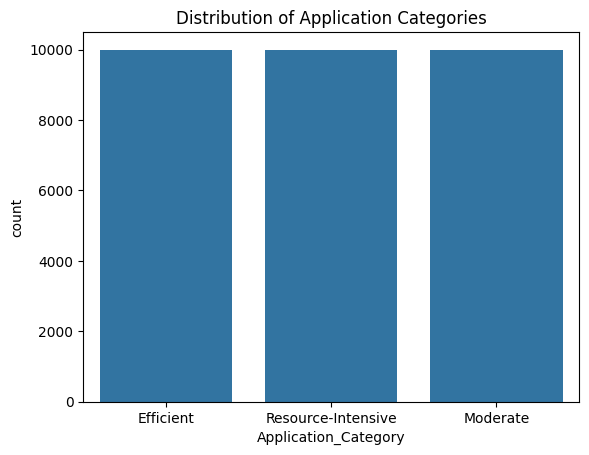

In [18]:
sns.countplot(x="Application_Category", data=df)
plt.title("Distribution of Application Categories")
plt.show()

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

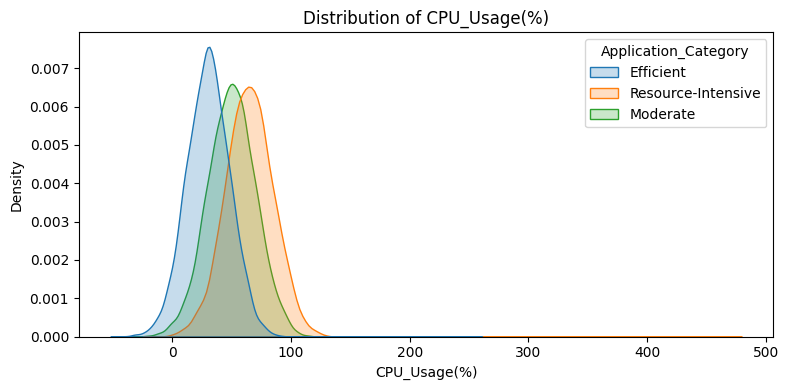

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

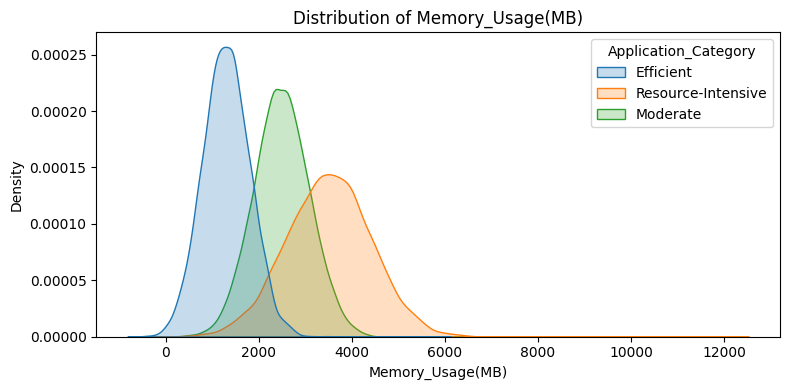

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

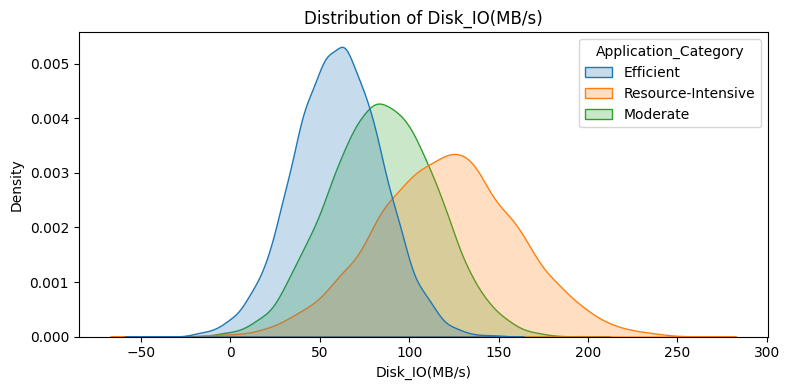

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

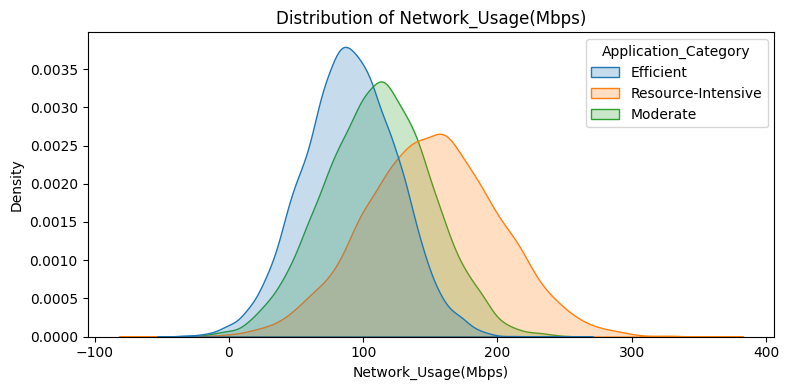

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

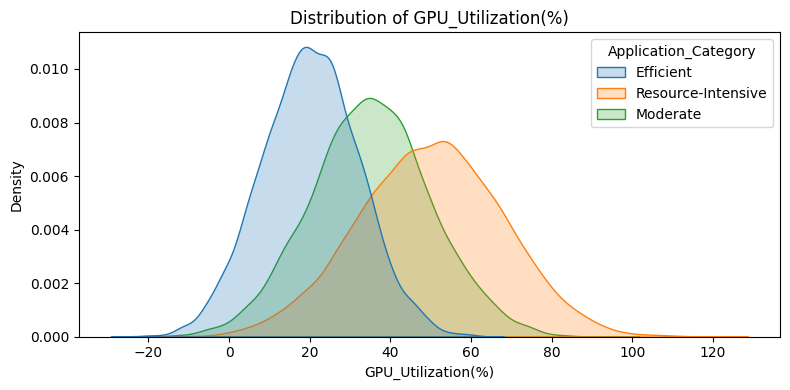

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

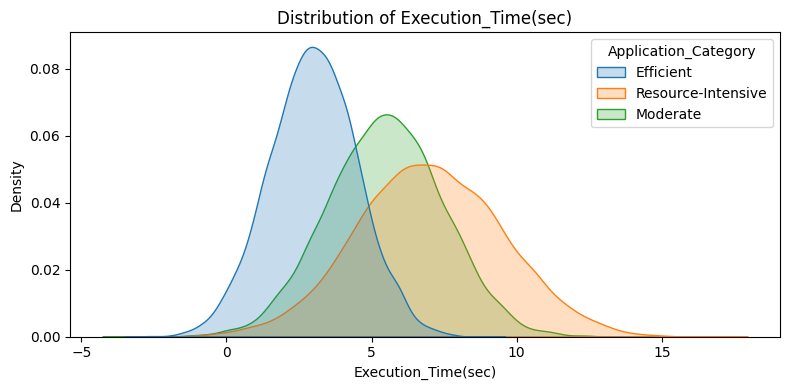

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

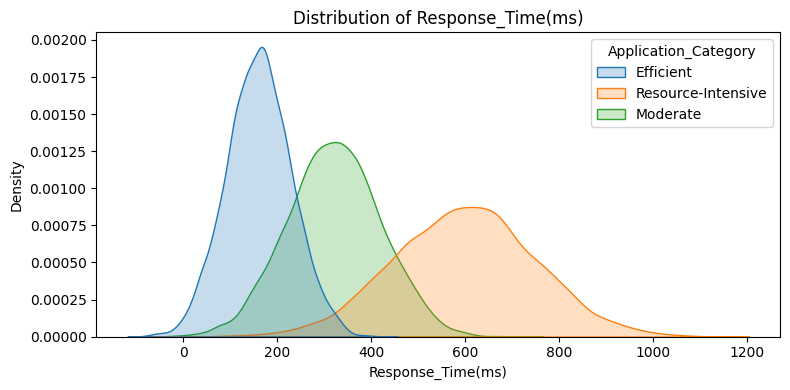

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

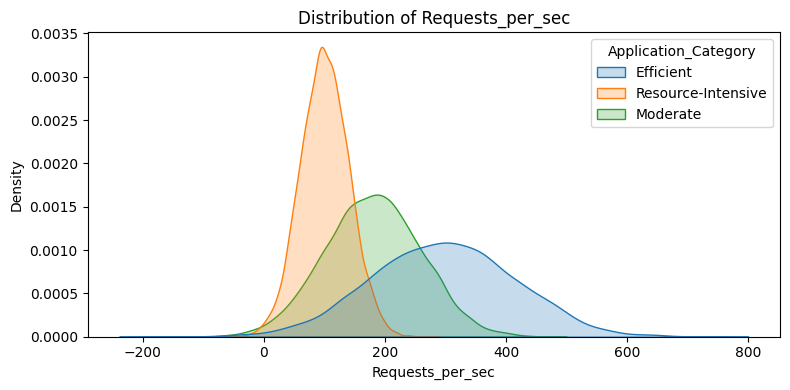

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

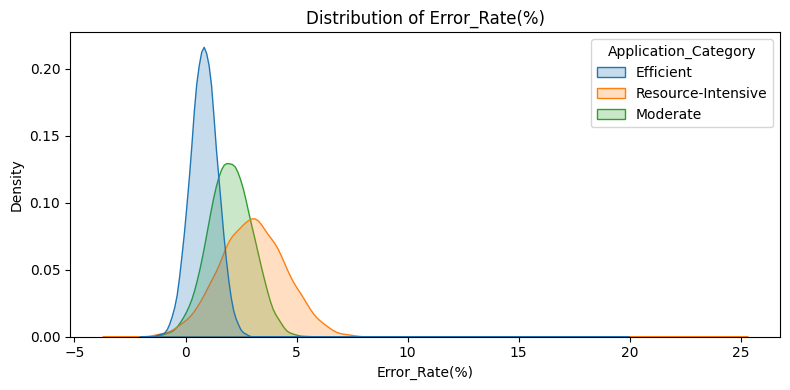

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

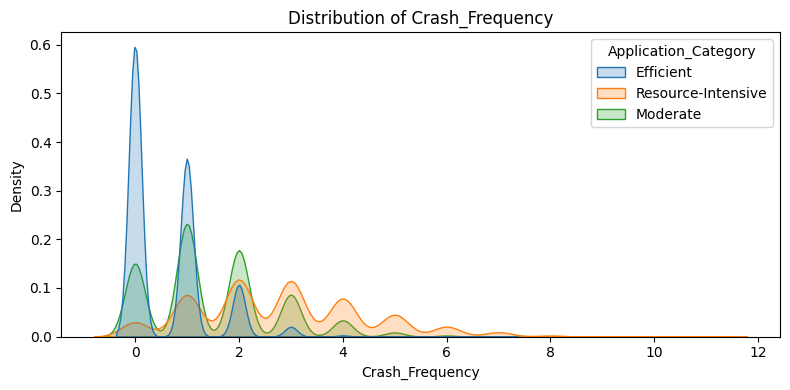

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

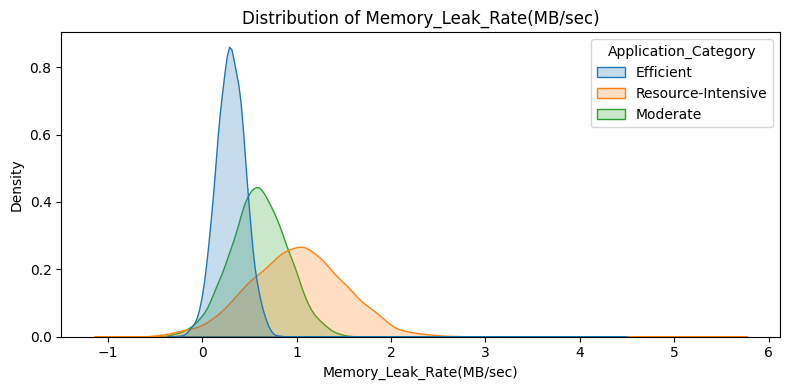

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

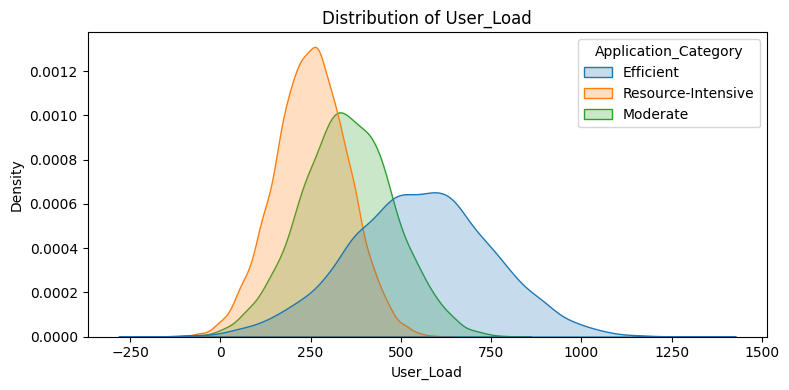

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

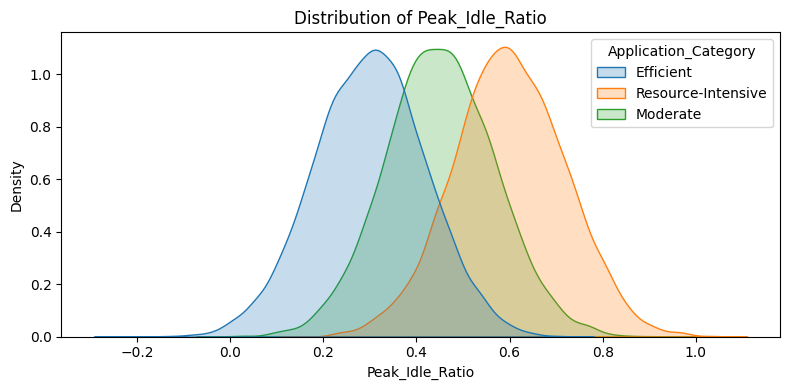

In [19]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=col, hue="Application_Category", fill=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


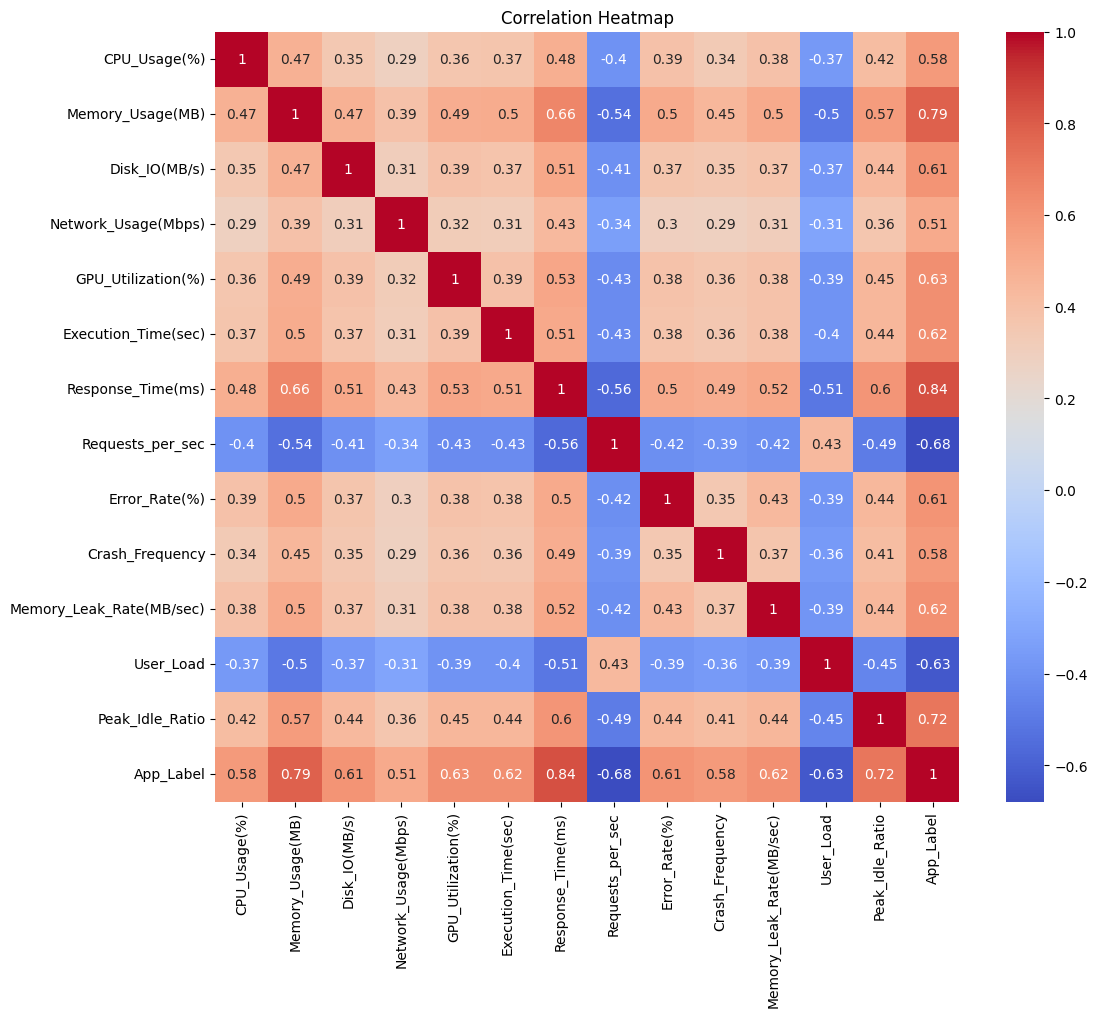

Top positively correlated features:
 Response_Time(ms)      0.840262
Memory_Usage(MB)       0.786689
Peak_Idle_Ratio        0.716692
GPU_Utilization(%)     0.625607
Execution_Time(sec)    0.621830
Name: App_Label, dtype: float64

Top negatively correlated features:
 Crash_Frequency        0.579917
CPU_Usage(%)           0.578399
Network_Usage(Mbps)    0.506042
User_Load             -0.629394
Requests_per_sec      -0.679181
Name: App_Label, dtype: float64


In [20]:
df_encoded = df.copy()
le = LabelEncoder()
df_encoded["App_Label"] = le.fit_transform(df_encoded["Application_Category"])

# Correlation matrix
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Top features most correlated with App_Label
corr_target = corr["App_Label"].drop("App_Label").sort_values(ascending=False)
print("Top positively correlated features:\n", corr_target.head())
print("\nTop negatively correlated features:\n", corr_target.tail())


/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


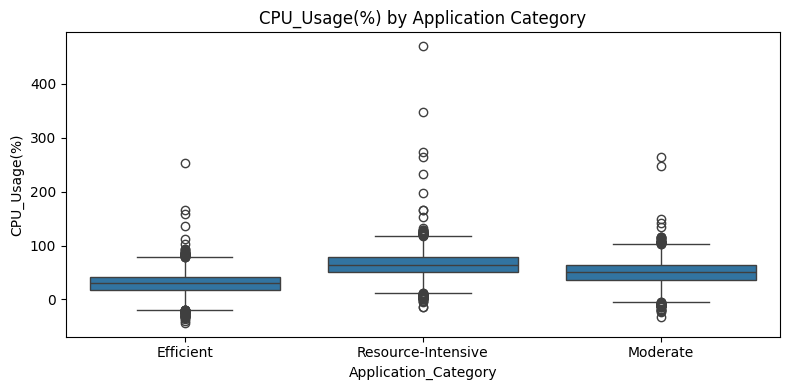

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


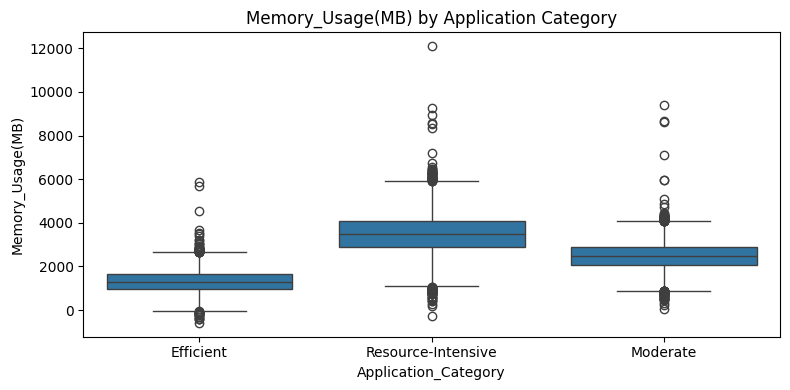

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


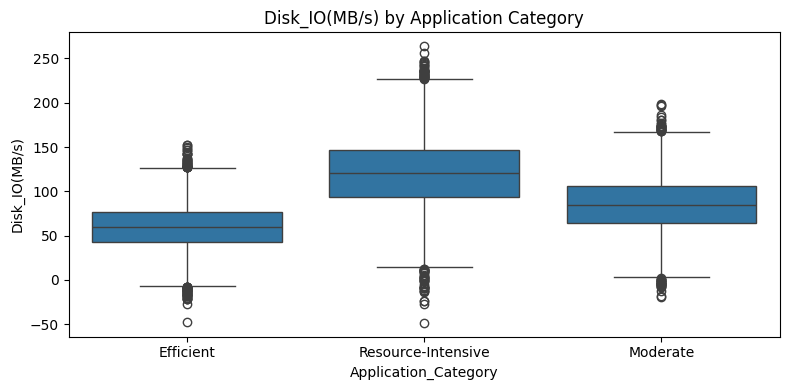

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


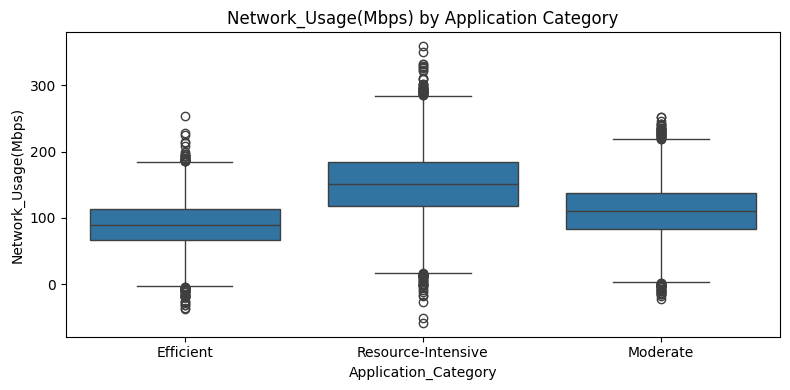

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


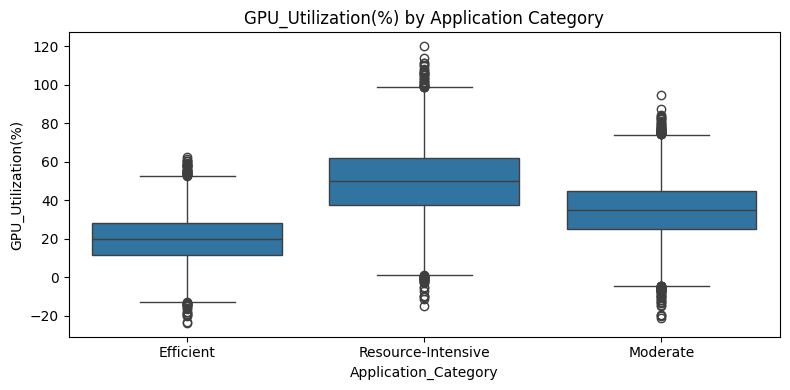

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


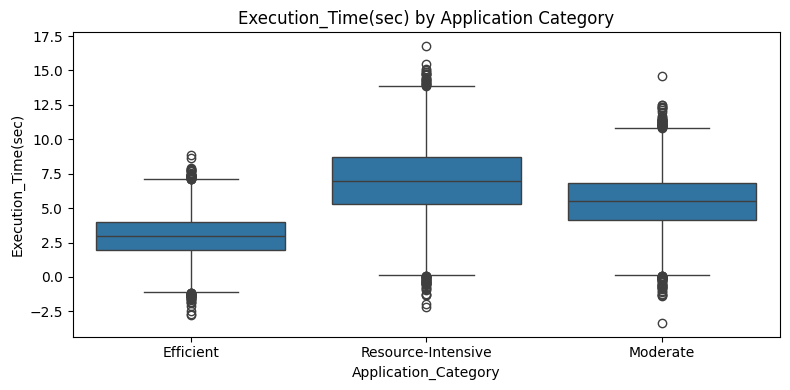

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


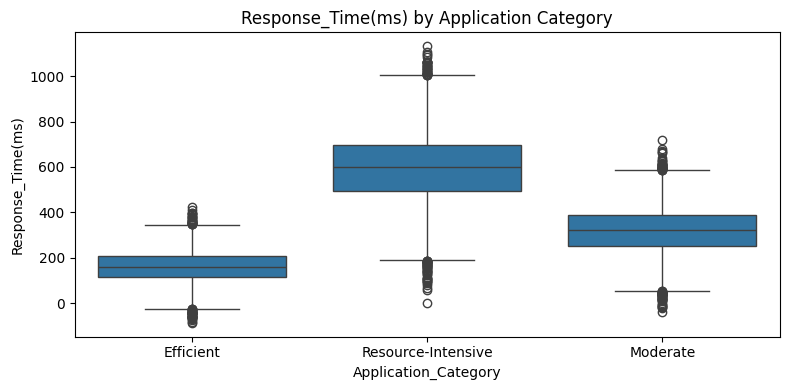

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


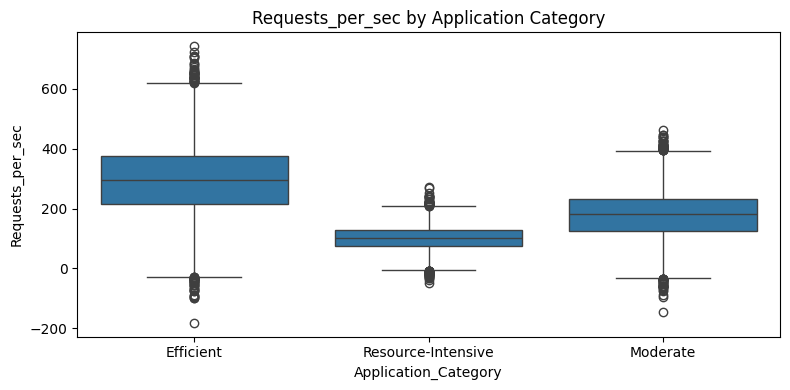

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


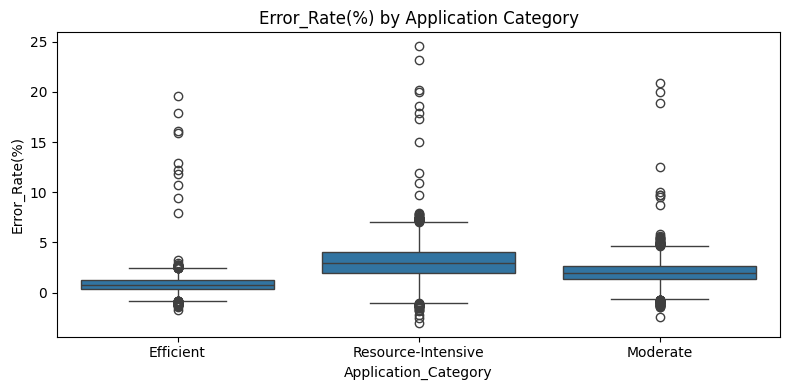

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


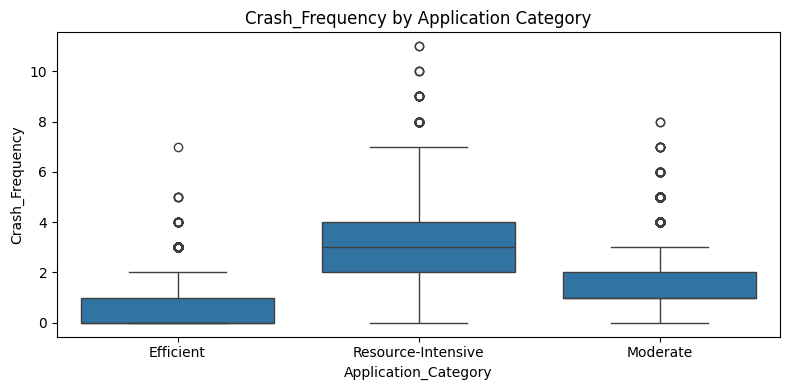

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


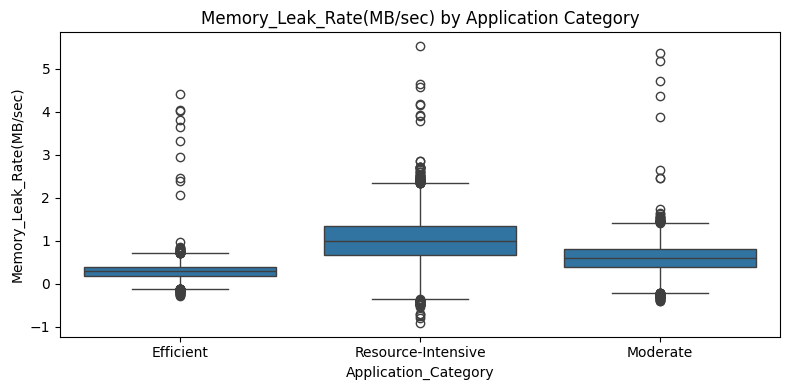

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


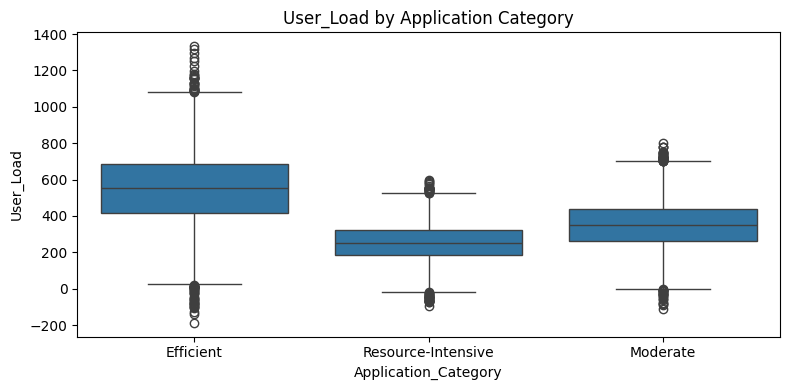

/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


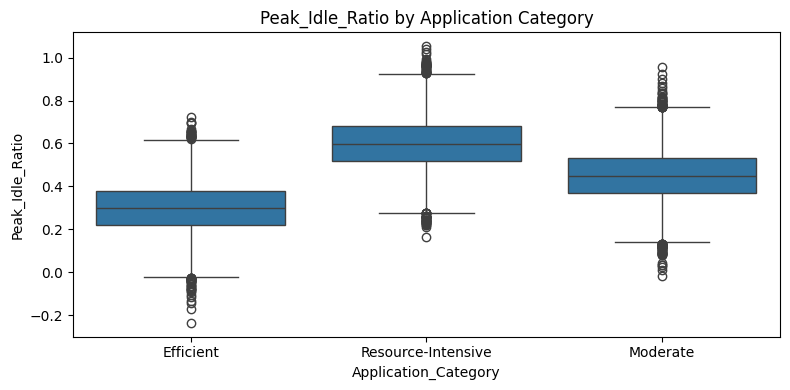

In [21]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="Application_Category", y=col, data=df)
    plt.title(f"{col} by Application Category")
    plt.tight_layout()
    plt.show()


/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/raghava/Documents/Projects/4-Report Generator and Load Runner/report-automation-website/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass

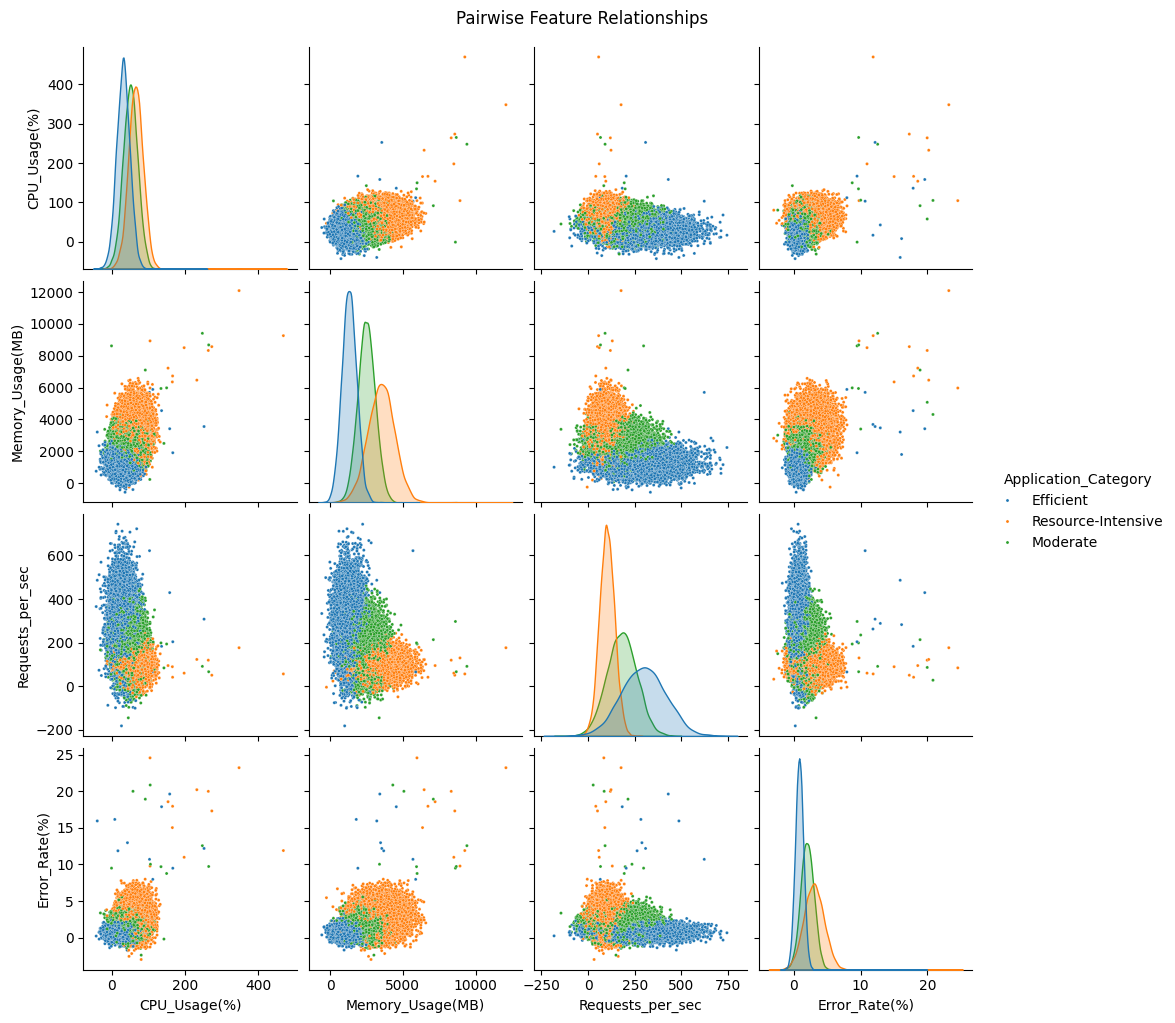

In [22]:
sns.pairplot(df_encoded, hue="Application_Category", 
             vars=["CPU_Usage(%)", "Memory_Usage(MB)", "Requests_per_sec", "Error_Rate(%)"], plot_kws={"s": 5})
plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()


In [23]:
X = df_encoded.drop(columns=["Application_Category", "App_Label"])
y = df_encoded["App_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=0.2, random_state=42)


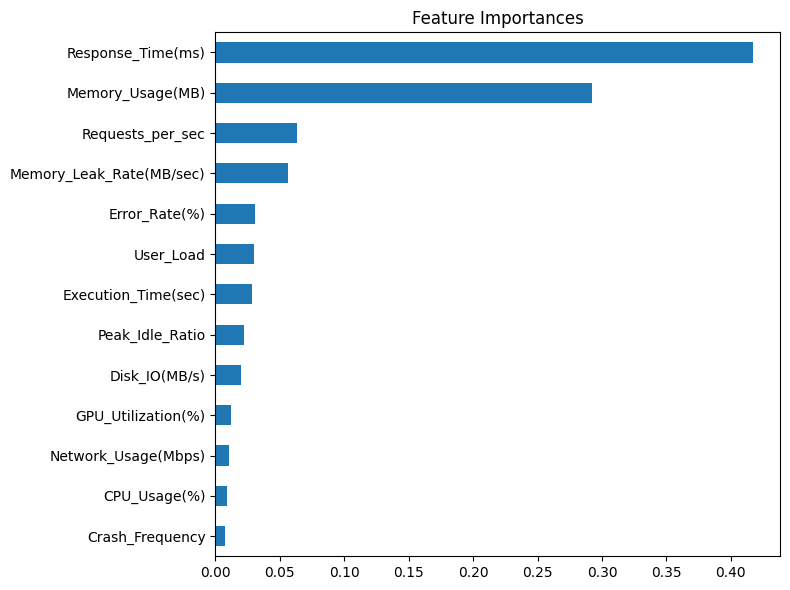

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8, 6), title="Feature Importances")
plt.tight_layout()
plt.show()

In [25]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svm_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=42))
svm_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(probability=True, random_state=42))])

In [26]:
from sklearn.neural_network import MLPClassifier

mlp_model = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))
mlp_model.fit(X_train, y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                               random_state=42))])


===== Decision Tree Evaluation =====
                    precision    recall  f1-score   support

         Efficient       0.97      0.96      0.97      2000
          Moderate       0.92      0.92      0.92      2000
Resource-Intensive       0.94      0.95      0.95      2000

          accuracy                           0.94      6000
         macro avg       0.94      0.94      0.94      6000
      weighted avg       0.94      0.94      0.94      6000



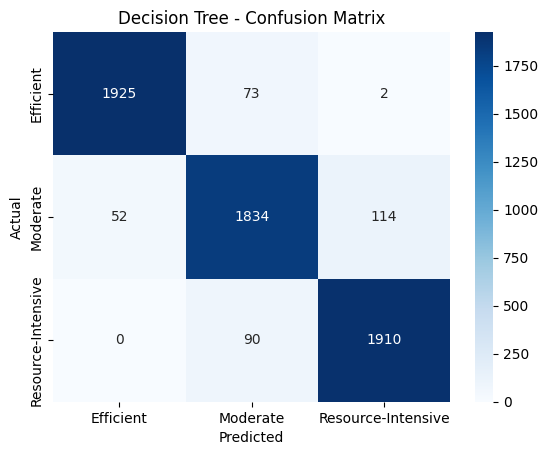


===== SVM Evaluation =====
                    precision    recall  f1-score   support

         Efficient       0.99      0.99      0.99      2000
          Moderate       0.97      0.98      0.98      2000
Resource-Intensive       0.99      0.98      0.98      2000

          accuracy                           0.98      6000
         macro avg       0.98      0.98      0.98      6000
      weighted avg       0.98      0.98      0.98      6000



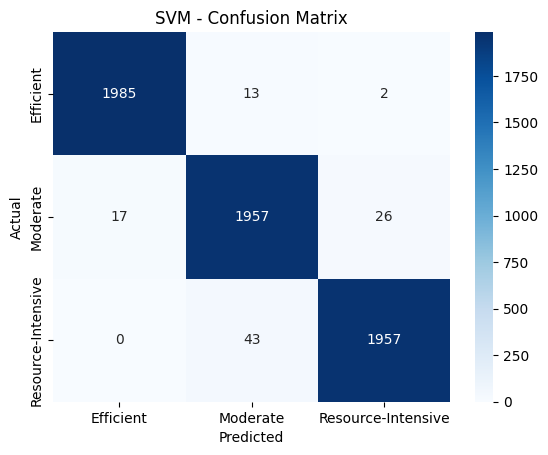


===== Neural Network Evaluation =====
                    precision    recall  f1-score   support

         Efficient       0.99      0.99      0.99      2000
          Moderate       0.96      0.97      0.96      2000
Resource-Intensive       0.97      0.97      0.97      2000

          accuracy                           0.98      6000
         macro avg       0.98      0.98      0.98      6000
      weighted avg       0.98      0.98      0.98      6000



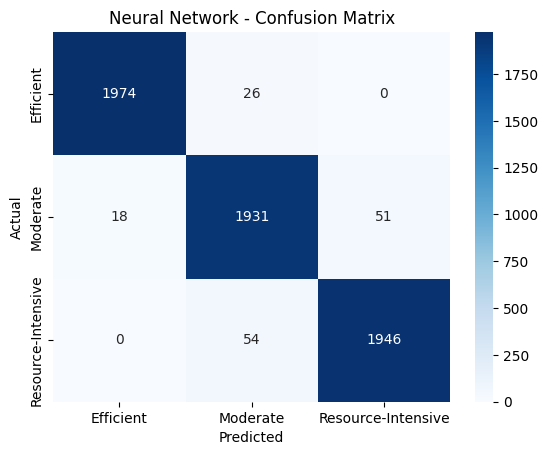

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, name):
    print(f"\n===== {name} Evaluation =====")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

evaluate_model(dt_model, X_test, y_test, "Decision Tree")
evaluate_model(svm_model, X_test, y_test, "SVM")
evaluate_model(mlp_model, X_test, y_test, "Neural Network")


In [ ]:
import joblib

# Save the best model — choose based on accuracy/F1
joblib.dump(svm_model, "app_perf_classifier_model.joblib")
joblib.dump(le, "app_classify_label_encoder.joblib")  # save label encoder too


In [28]:
import joblib

# Load the saved model and label encoder
model = joblib.load("app_perf_classifier_model.joblib")
label_encoder = joblib.load("app_classify_label_encoder.joblib")


In [29]:
new_data = {
    "CPU_Usage(%)": 45,
    "Memory_Usage(MB)": 1800,
    "Disk_IO(MB/s)": 60,
    "Network_Usage(Mbps)": 90,
    "GPU_Utilization(%)": 25,
    "Execution_Time(sec)": 4,
    "Response_Time(ms)": 250,
    "Requests_per_sec": 180,
    "Error_Rate(%)": 1.2,
    "Crash_Frequency": 0.5,
    "Memory_Leak_Rate(MB/sec)": 0.4,
    "User_Load": 320,
    "Peak_Idle_Ratio": 0.35
}

import pandas as pd

new_df = pd.DataFrame([new_data])


# Predict numerical class
predicted_class = model.predict(new_df)[0]

# Convert to readable label
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

print("Predicted Application Category:", predicted_label)


Predicted Application Category: Efficient


In [30]:
proba = model.predict_proba(new_df)[0]
for cls, p in zip(label_encoder.classes_, proba):
    print(f"{cls}: {p:.2f}")


Efficient: 0.62
Moderate: 0.38
Resource-Intensive: 0.00


In [31]:
print(proba)

[6.18725817e-01 3.81215350e-01 5.88329324e-05]


In [32]:
# Define class score mapping
score_mapping = {
    "Efficient": 0.0,
    "Moderate": 0.5,
    "Resource-Intensive": 1.0
}

# Get probabilities for each class
proba = model.predict_proba(new_df)[0]

# Map labels to numeric scores
class_labels = label_encoder.classes_
class_scores = [score_mapping[label] for label in class_labels]

# Calculate weighted score
final_score = sum(p * s for p, s in zip(proba, class_scores))

# Predicted label (for display)
predicted_label = label_encoder.inverse_transform([model.predict(new_df)[0]])[0]

# Output
print(f"Predicted Category: {predicted_label}")
print(f"Weighted Performance Score: {final_score:.2f}")


Predicted Category: Efficient
Weighted Performance Score: 0.19
